# Next-Day Load Profile Forecasting with GRU

Forecast the next 24-hour load profile from the previous seven daily profiles of the same building.

## 0. Setup

In [1]:
from pathlib import Path
import random

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader

from src.rnn_forecast.artifacts import save_run
from src.rnn_forecast.data import (
    DailyForecastDataset, fit_normalization, load_daily_profiles, make_forecast_splits,
)
from src.rnn_forecast.engine import evaluate, summarize_test, train_model
from src.rnn_forecast.model import LoadProfileGRU
from src.rnn_forecast.plots import plot_forecast_examples, plot_learning_curves

## 1. Load data

In [2]:
SEED = 42
LOOKBACK_DAYS = 7
BATCH_SIZE = 128
MAX_EPOCHS = 30
PATIENCE = 6
LEARNING_RATE = 1e-3
DATA_DIR = Path('dataset/load_energy_3class_daily')
OUTPUT_DIR = Path('outputs/rnn_load_profile_forecast')

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

building_rows, hourly = load_daily_profiles(DATA_DIR)
print('Device:', device)
print('Buildings:', len(building_rows), '| Daily profiles:', len(hourly))
print('Date range:', min(rows[0]['date'] for rows in building_rows.values()),
      'to', max(rows[-1]['date'] for rows in building_rows.values()))

Device: cpu
Buildings: 20 | Daily profiles: 6720
Date range: 2019-07-31 to 2020-06-30


## 2. Build chronological sequences

In [3]:
train_sequences, val_sequences, test_sequences = make_forecast_splits(
    building_rows, lookback_days=LOOKBACK_DAYS
)
for name, sequences in [('Train', train_sequences), ('Validation', val_sequences), ('Test', test_sequences)]:
    print(f'{name:10s} {len(sequences):4d} targets | {sequences[0]["target_date"]} to {sequences[-1]["target_date"]}')

normalization = fit_normalization(train_sequences, hourly)
train_dataset = DailyForecastDataset(train_sequences, hourly, normalization)
val_dataset = DailyForecastDataset(val_sequences, hourly, normalization)
test_dataset = DailyForecastDataset(test_sequences, hourly, normalization)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

inputs, target = train_dataset[0]
print('RNN input shape:', tuple(inputs.shape), '| Next-day target shape:', tuple(target.shape))

Train      3940 targets | 2019-08-07 to 2020-02-19
Validation 1320 targets | 2020-02-20 to 2020-04-25
Test       1320 targets | 2020-04-26 to 2020-06-30
RNN input shape: (7, 24) | Next-day target shape: (24,)


## 3. Build the architecture

In [4]:
model = LoadProfileGRU(input_size=24, hidden_size=64, num_layers=2, dropout=0.2).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
print(model)
print('Trainable parameters:', sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad))

LoadProfileGRU(
  (gru): GRU(24, 64, num_layers=2, batch_first=True, dropout=0.2)
  (head): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=24, bias=True)
  )
)
Trainable parameters: 47960


## 4. Train the model

In [5]:
history, best_epoch, best_val_mae = train_model(
    model, train_loader, val_loader, criterion, optimizer, device, normalization,
    max_epochs=MAX_EPOCHS, patience=PATIENCE,
)
print('Best epoch:', best_epoch, '| Validation MAE:', round(best_val_mae, 3))

Epoch 01 | train MSE 0.0434 | val MAE 71.506 | val RMSE 143.429
Epoch 02 | train MSE 0.0127 | val MAE 39.743 | val RMSE 96.396
Epoch 03 | train MSE 0.0096 | val MAE 32.235 | val RMSE 78.849
Epoch 04 | train MSE 0.0076 | val MAE 28.403 | val RMSE 68.460
Epoch 05 | train MSE 0.0068 | val MAE 30.933 | val RMSE 76.851
Epoch 06 | train MSE 0.0063 | val MAE 23.723 | val RMSE 60.337
Epoch 07 | train MSE 0.0058 | val MAE 22.982 | val RMSE 54.598
Epoch 08 | train MSE 0.0054 | val MAE 21.949 | val RMSE 47.678
Epoch 09 | train MSE 0.0054 | val MAE 17.293 | val RMSE 42.655
Epoch 10 | train MSE 0.0050 | val MAE 19.534 | val RMSE 46.589
Epoch 11 | train MSE 0.0048 | val MAE 18.795 | val RMSE 45.846
Epoch 12 | train MSE 0.0047 | val MAE 23.277 | val RMSE 55.587
Epoch 13 | train MSE 0.0047 | val MAE 21.253 | val RMSE 50.385
Epoch 14 | train MSE 0.0046 | val MAE 18.652 | val RMSE 44.483
Epoch 15 | train MSE 0.0046 | val MAE 22.297 | val RMSE 52.813
Early stopping at epoch 15
Best epoch: 9 | Validation 

## 5. Evaluate forecast

In [6]:
test_result = evaluate(model, test_loader, criterion, device, normalization)
metrics = summarize_test(test_result)
for name, value in metrics.items():
    print(f'{name}: {value:.4f}')

test_normalized_mse: 0.0021
test_mae: 19.6182
test_rmse: 61.7551
test_wape_percent: 10.8320


## 6. Visualize forecasts

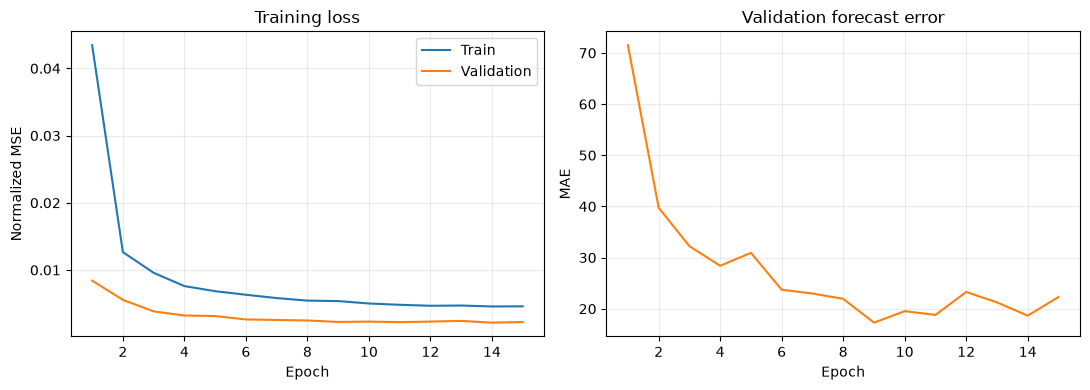

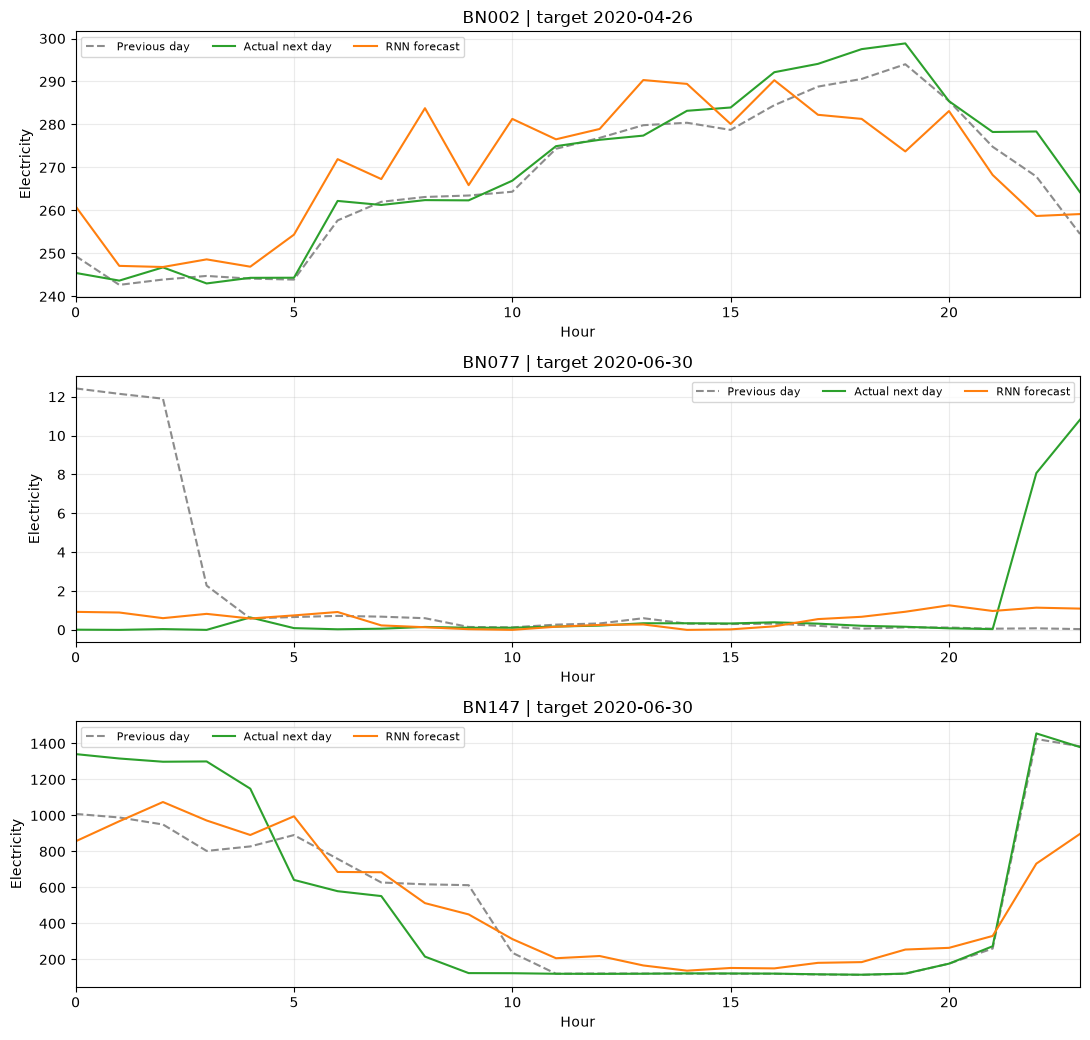

In [7]:
fig = plot_learning_curves(history, OUTPUT_DIR / 'training_curves.png')
plt.show()

fig = plot_forecast_examples(
    test_sequences, hourly, test_result['actual'], test_result['predicted'],
    OUTPUT_DIR / 'forecast_examples.png',
)
plt.show()

## 7. Save the results

In [8]:
report = save_run(
    OUTPUT_DIR, model, history, metrics,
    (train_sequences, val_sequences, test_sequences),
    normalization, SEED, best_epoch, LOOKBACK_DAYS,
)
print('Saved to:', OUTPUT_DIR.resolve())
print('Test MAE:', round(report['test_mae'], 3),
      '| Test RMSE:', round(report['test_rmse'], 3),
      '| Test WAPE:', round(report['test_wape_percent'], 3), '%')

Saved to: /Users/zendi.iklima/Documents/UTP/My Lectures/Intelligence System/Scripts/outputs/rnn_load_profile_forecast
Test MAE: 19.618 | Test RMSE: 61.755 | Test WAPE: 10.832 %
